In [1]:
import os, argparse, typing
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

import numpy as np
import pandas as pd
import scanpy as sc
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from functools import partial
import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

import PINN
from PINN import models as models
from PINN import reader 
from PINN import functions as fns

In [2]:
import matplotlib.pyplot as plt
from importlib import reload

In [3]:
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [4]:
device = "cuda:5"

# load dataset

In [5]:
# load the anndata
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

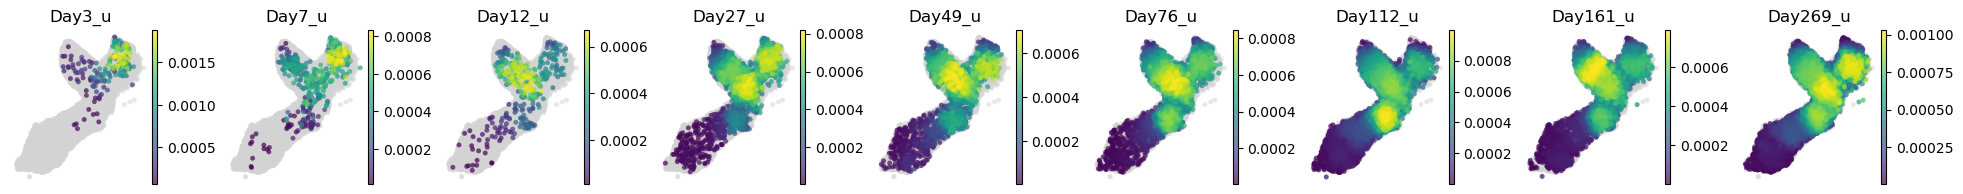

In [6]:
PINN.pl.umap_by_time(lambda x: f'Day{x}_u', ery_mk_ad);

In [7]:
# only using the first 5 timepoints
n_timepoint = 5
train_DS_t5 = reader.HigDim_AnnDS(AnnData=ery_mk_ad, n_timepoint=5,  
                              cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
                              log_transform=False
                              )
train_DS_t9 = reader.HigDim_AnnDS(AnnData=ery_mk_ad,  
                              cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
                              log_transform=False
                              )
density_funs = train_DS_t9.density_funs

T_b_max = np.log(train_DS_t5.popD['t'].max())

# getting processed cell state and density from DataSet
t5_ad = train_DS_t5.adata.copy()
u_b = train_DS_t5.u_b.cpu().numpy().reshape(n_timepoint, -1)

s_all = train_DS_t5.s.float().requires_grad_()
t_b = train_DS_t5.t_b.float().requires_grad_()

# MLP woPL 

In [24]:
reload(models)

<module 'PINN.models' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/__init__.py'>

In [25]:
# time sensitive modeling
coll_all = models.MLP_PINN.load_from_checkpoint(
    "logs/ery_mk-DM_EigenVectors_multiBnch/MLP_PINN_tsense/lightning_logs/version_3/checkpoints/epoch=275-total_loss=0.00002821.ckpt"
)

MLP_tins = models.MLP_PINN.load_from_checkpoint(
    "logs/ery_mk-DM_EigenVectors_multiBnch/MLP_PINN/lightning_logs/version_0/checkpoints/epoch=298-total_loss=0.00006086.ckpt"
)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [26]:
param_pred = MLP_tins.predict_param(train_DS_t5, param='u');
PINN.pl.params_in_umap(t5_ad, u_b, param='u', copy=False);
PINN.pl.params_in_umap(t5_ad, param_pred, param='u_pred', copy=False);
    

prediction of shape (5, 4321)


TypeError: umap_by_time() got multiple values for argument 'cell_of_t'

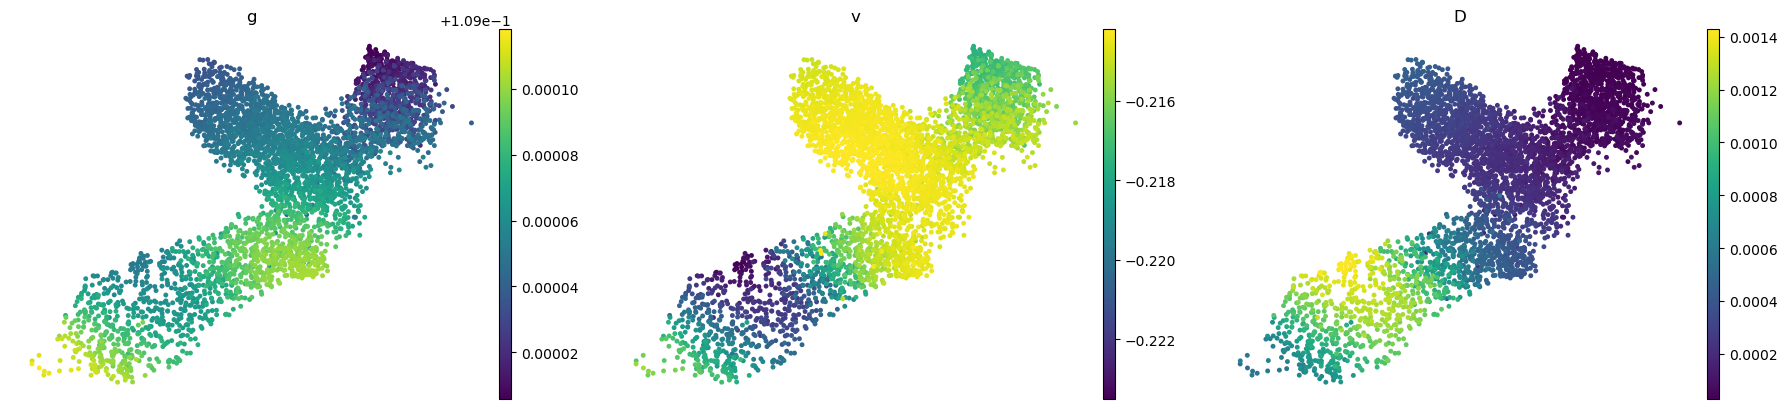

In [ ]:
dynamics_params = ['g', 'v', 'D']

for param in dynamics_params:
    t5_ad.obs[param] = MLP_tins.predict_param(train_DS_t5, param=param);

sc.pl.umap(t5_ad, color=dynamics_params, ncols=3, frameon=False, size=50)    

In [ ]:
torch.cuda.empty_cache()
s = train_DS_t5.s.clone().float().requires_grad_()
t = train_DS_t5.t_b.clone().float().requires_grad_()

In [ ]:
MLP_tins = models.MLP_PINN.load_from_checkpoint(
    "logs/ery_mk-DM_EigenVectors_multiBnch/MLP_PINN/lightning_logs/version_0/checkpoints/epoch=298-total_loss=0.00006086.ckpt"
)
device = MLP_tins.device
s = s.to(device)
t = t.to(device)

u = MLP_tins.u(s,t)
D = MLP_tins.D(s,t)
v = MLP_tins.v(s,t)
g = MLP_tins.g(s,t) # d- dim

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [ ]:
D

tensor([3.0898e-05, 4.6736e-04, 1.4268e-04,  ..., 2.3122e-04, 6.3787e-04,
        3.1152e-05], device='cuda:6', grad_fn=<SqueezeBackward1>)

## visualize the terms

In [ ]:
def pred_to_nday(x, n_timepoint=5, n_dim=5): 
    """
    use to reshape prediction
    """
    nday = x.detach().cpu().numpy().reshape(n_timepoint,-1)

    if nday.shape[-1] != 4321:
        nday = nday.reshape(n_timepoint, -1, n_dim)

    return nday


def vis_equation_term(model, s_all, t_b, terms='all'):
    """
    visaulize the terms output by the equation

    term : str,  one of dudt, growth, drift, diffuse
    """

    device = model.device
    
    dudt, growth, drift, diffuse = model.simplified_equation(s_all.to(device), t_b.to(device))

    # reshape
    growth = pred_to_nday(growth)
    drift = pred_to_nday(drift)
    dudt = pred_to_nday(dudt)
    diffuse = pred_to_nday(diffuse)
    residual = dudt - (growth - drift)

    if terms == 'all':
        # compute everything
        terms = ["growth", 'drift', 'dudt', 'diffuse', 'residual']
    else:
        terms = [terms] if len(terms)==1 else terms

    for term in terms:
        for i, t in enumerate(train_DS_t5.popD['t']):
            # t5_ad.obs[f'Day{t}_{}'] = u[i]
            t5_ad.obs[f'Day{t}_{term}'] = eval(term)[i]
            
        PINN.pl.umap_by_time(lambda x: f'Day{x}_{term}', t5_ad,train_DS_t5.popD['t']);

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


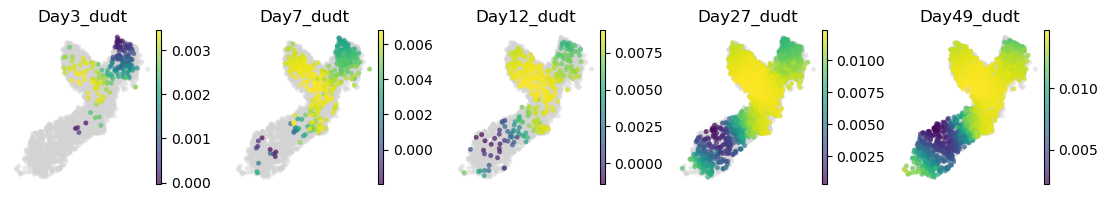

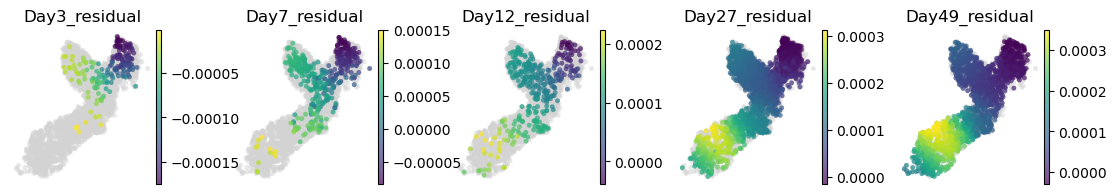

In [ ]:
MLP_tins = models.MLP_PINN.load_from_checkpoint(
    "logs/ery_mk-DM_EigenVectors_multiBnch/MLP_PINN/lightning_logs/version_0/checkpoints/epoch=298-total_loss=0.00006086.ckpt"
)
device = MLP_tins.device
s = train_DS_t5.s.clone().float().requires_grad_()
t = train_DS_t5.t_b.clone().float().requires_grad_()

vis_equation_term(MLP_tins, s, t, terms=["dudt", "residual"])

# cumulative different of 

In [8]:
ext_u_from_t5 = [u_b]

for i_t in [5, 6,7,8]:
    print(f'i_t {i_t} is', train_DS_t9.popD['t'][i_t])

    ub_ext = density_funs[i_t](train_DS_t5.cellstate.T)
    ub_ext = ub_ext / ub_ext.sum()
    ub_ext = ub_ext * train_DS_t9.popD['mean'][i_t]

    ext_u_from_t5.append(ub_ext)

i_t 5 is 76


i_t 6 is 112
i_t 7 is 161
i_t 8 is 269


In [9]:
u_b_extend = np.vstack(ext_u_from_t5)
u_b_extend.shape

(9, 4321)

In [10]:
u_different = np.diff(u_b_extend, axis=0)

In [11]:
u_different.shape

(8, 4321)

prediction of shape (5, 4321)


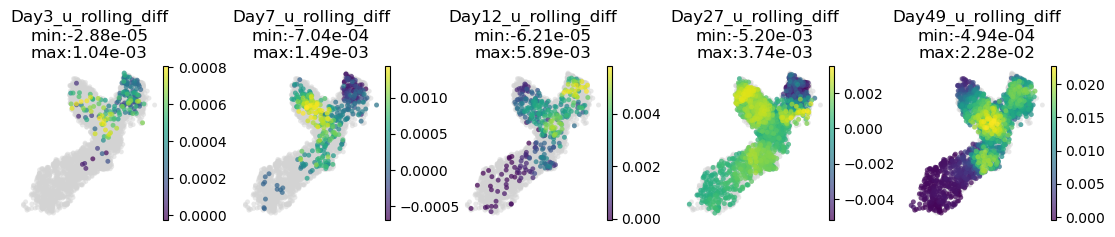

In [15]:
PINN.pl.params_in_umap(t5_ad, u_different[:5], param='u_rolling_diff', cell_of_t=False);